number of pulsars 229744

Computing for quantile=10.00, flux threshold=0.00
Done in 244.7s

Computing for quantile=10.00, flux threshold=0.00
Done in 174.3s

Computing for quantile=10.00, flux threshold=0.00
Done in 137.5s

Computing for quantile=10.00, flux threshold=0.00
Done in 33.9s

Computing for quantile=10.00, flux threshold=0.00
Done in 4.7s


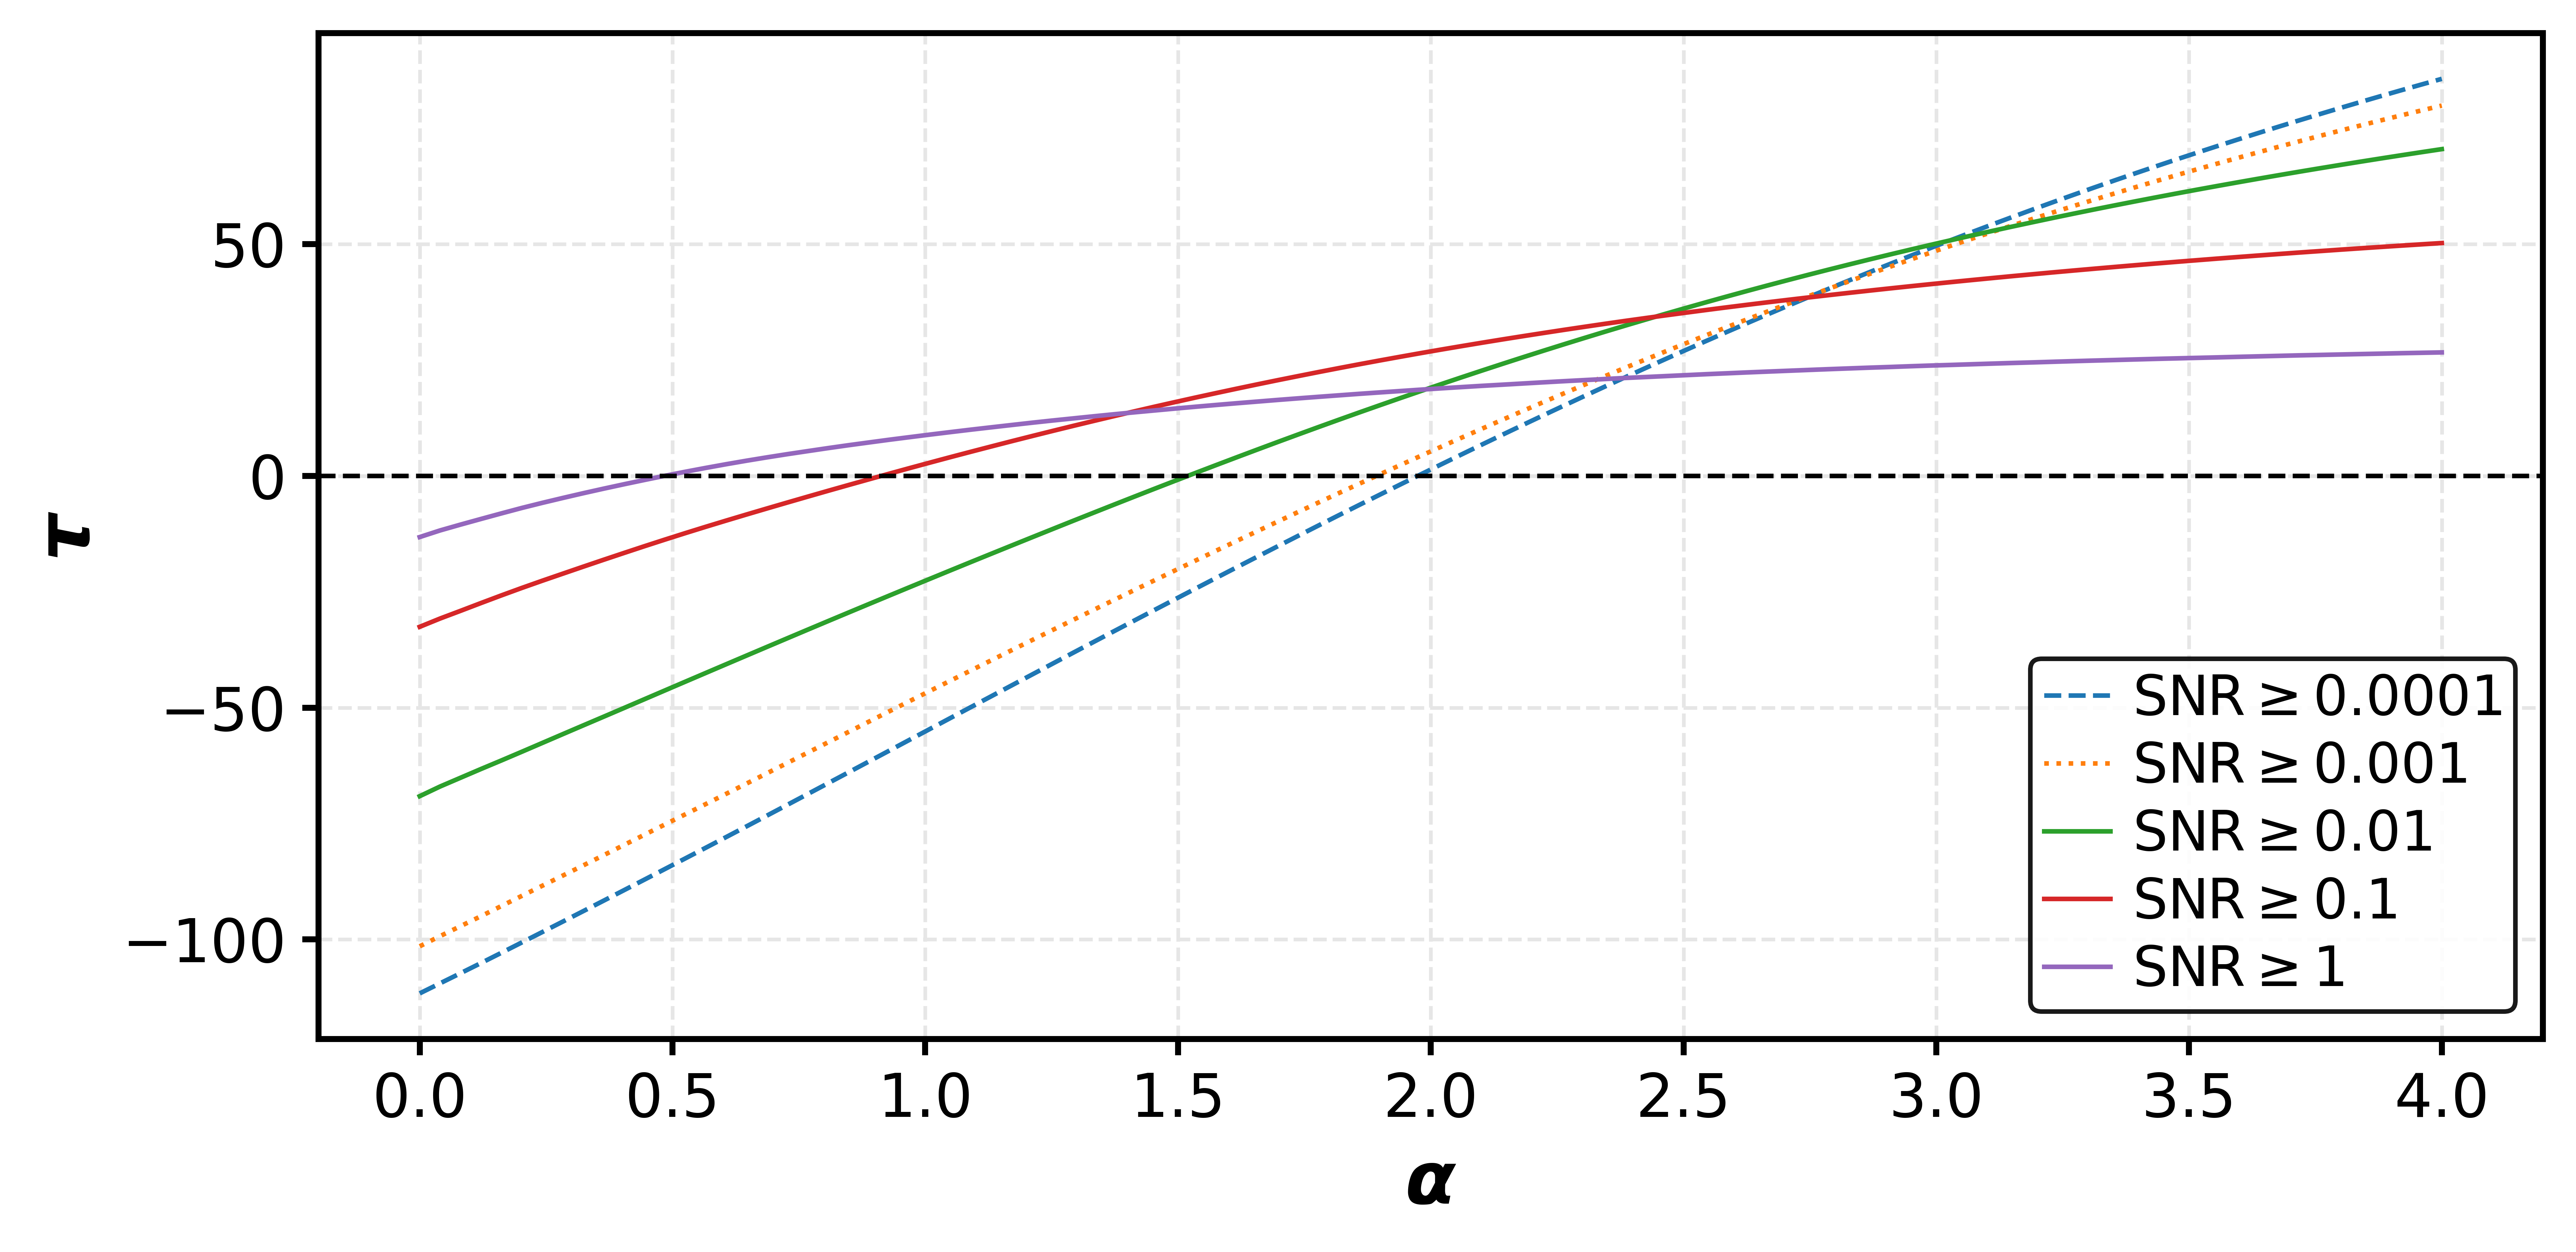

In [7]:
%reset -f
from psrpoppy import population
import pickle
import sys
import matplotlib.pyplot as plt
import psrpoppy.population as real_population
import pandas as pd
import numpy as np
import multiprocessing
import time
from numba import njit
import sys
sys.path.append('/home/sanjith/paper/default_pop/PsrPopPy_2000/psrpoppy')

import matplotlib as mpl

#GLOBAL STYLE SETTINGS
mpl.rcParams.update({
    "font.size": 14,                
    "axes.labelweight": "bold",    
    "axes.titlesize": 16,          
    "axes.titleweight": "bold",
    "axes.linewidth": 1.3,         
    "lines.linewidth": 1,        
    "legend.fontsize": 12,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
})



sys.modules['population'] = real_population
filename='PMSURV_SNR_-10.results'


#df_smr = pd.read_excel("/home/sanjith/PsrPopPy/df_smr.xlsx")


with open(filename, 'rb') as f:
    pop = pickle.load(f)


fluxes = np.array([psr.s_1400() for psr in pop.population])*1e-26
distances = np.array([psr.dtrue for psr in pop.population])*1e3  #pc
snr=np.array([psr.snr for psr in pop.population])
n_samples = len(fluxes)
print("number of pulsars",n_samples)

df = pd.DataFrame({
    'Flux': fluxes,
    'Distance': distances,
    'snr':snr
})
plt.figure(figsize=(8,4),dpi=1000)
SNR_linestyle = {
    0.0001: '--',   # dashed
    0.001:  ':',    # dotted
    0.01:   '-',    # solid
    0.1:    '-',    # solid
    1:      '-'    # solid
    #9:      '-'    # solid
}


for i in [0.0001,0.001,0.01,0.1,1]:
    df=df[df["snr"] >= i]  #selecting only positive snr's 


    #df = pd.concat([df, df_smr], ignore_index=True) #adding smeared pulsars  to the dataset

    #flux_cut=10**((-2-1.734)/1.06)
    #print("log_flux_cut",np.log10(flux_cut))

    
    df['Flux_log'] = np.log10(df['Flux'])
    df['Dist_log'] = np.log10(df['Distance'])

    def compute_LogLth(D_array, flux_thresh, alpha):
        return np.log10(flux_thresh) + alpha * np.log10(D_array)
    
    @njit
    def compute_tau_numba(D_logs, Lprime_logs, thresh, alpha):
        n = len(D_logs)
        N_a = np.zeros(n, dtype=np.int64)
        R_a = np.zeros(n, dtype=np.int64)
        E_a = np.zeros(n)
        V_a = np.zeros(n)

        for i in range(n):
            Di = D_logs[i]
            Li = Lprime_logs[i]
            L_thi = np.log10(thresh * (10 ** Di) ** alpha)
            N_count = 0
            R_count = 0
            for j in range(n):
                D = D_logs[j]
                L = Lprime_logs[j]
                if (D <= Di) and (L >= L_thi):
                    N_count += 1
                    if Li >= L:
                        R_count += 1
            N_a[i] = N_count
            R_a[i] = R_count
            E_a[i] = 0.5 * (N_count + 1)
            V_a[i] = (N_count ** 2 - 1) / 12 if N_count > 0 else 0.0

        numerator = np.sum(R_a - E_a)
        denominator = np.sqrt(np.sum(V_a))
        return numerator / denominator if denominator != 0 else np.nan

    def compute_tau_for_alpha(alpha_thresh):
        alpha, thresh = alpha_thresh

        
        LogLthA = compute_LogLth(df['Distance'].values, thresh, alpha)

        
        Lprime_Log = df['Flux_log'].values + alpha * df['Dist_log'].values

       
        mask = Lprime_Log >= LogLthA
        D_logs = df['Dist_log'].values[mask]
        Lprime_logs = Lprime_Log[mask]

        if len(D_logs) == 0:
            return alpha, np.nan

        tau = compute_tau_numba(D_logs, Lprime_logs, thresh, alpha)
        return alpha, tau

    if __name__ == '__main__':
        #plt.figure(figsize=(8,6))

        quantiles = [10]                                                            #no flux threshold removal 
        flux_thresholds = np.percentile(df["Flux"],quantiles)  #a

        alphas = np.linspace(0,4,100)

        for q, thresh in zip(quantiles, flux_thresholds):
            print(f"\nComputing for quantile={q:.2f}, flux threshold={thresh:.2f}")
            start = time.time()

            alpha_thresh_list = [(alpha, thresh) for alpha in alphas]

            # Limit number of parallel processes to save RAM :
            with multiprocessing.Pool(processes=4) as pool:
                results = pool.map(compute_tau_for_alpha, alpha_thresh_list)

            results.sort()
            taus = [tau for alpha, tau in results]

            print(f"Done in {time.time() - start:.1f}s")
            plt.plot(alphas, taus,linestyle=SNR_linestyle[i], label=fr"$\text{{SNR}} \geq {i}$")


plt.axhline(0, color='k', linestyle='--')
plt.xlabel(r'$\boldsymbol{\alpha}$', fontsize=16) 
plt.ylabel(r'$\boldsymbol{\tau}$', fontsize=16)
plt.legend(
    frameon=True,
    loc="lower right",
    facecolor='white',
    framealpha=0.9,
    edgecolor='black',
    borderpad=0.25,     
    labelspacing=0.25,   
    handlelength=1.2,    
    handletextpad=0.4,   
)


#plt.savefig("/mnt/e/pulsar/plots/efron_petrosian_tau_alpha_no smeared_lfl06_ne2001_a _0.001to1.pdf",dpi =1000,bbox_inches="tight")
plt.tight_layout()
plt.show()

